In [ ]:
import os
os.environ['TZ'] = 'Europe/Berlin'
 
import re

import pandas as pd
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import anndata as ad
from scipy.stats import spearmanr


import numpy as np

import scanpy as sc
import scipy.sparse as sp

In [24]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
NMF_DIR = f"{BASE}/results/09_HIHAtlas/09_03_nmf_downsampled"
DEG_PATH = f"{BASE}/results/10_integration_GBM_HIHA/10_09_deg_pDC_MP5_high_vs_low.csv"
OUT_DIR = f"{BASE}/results/10_integration_GBM_HIHA"
os.makedirs(OUT_DIR, exist_ok=True)
 
GENES_PATH = f"{NMF_DIR}/genes.csv"
PADJ_CUTOFF = 0.05
TOP_N_DEG = 200
LOGFC_CUTOFF = 2

MP5_LABEL_CANDIDATES = ["MP5", "HIHA_MP5"]

In [3]:
genes_raw = pd.read_csv(GENES_PATH)
mp5_genes = set(genes_raw.loc[genes_raw["mp"] == "MP5", "gene"].astype(str))
print(f"MP5 gene set: {len(mp5_genes)} genes")


MP5 gene set: 38 genes


In [26]:
deg_df = pd.read_csv(DEG_PATH)
print("\nDEG file shape:", deg_df.shape)
print("DEG file columns:", deg_df.columns.tolist())
 
sig_deg = deg_df[deg_df["pvals_adj"] < PADJ_CUTOFF].copy()
print(f"Significant DEG genes (padj < {PADJ_CUTOFF}): {len(sig_deg)} of {len(deg_df)} total")
 
sig_deg = sig_deg[sig_deg["logfoldchanges"].abs() > LOGFC_CUTOFF]
print(f"...of those, {len(sig_deg)} pass |logFC| > {LOGFC_CUTOFF}")
 
top_deg = sig_deg.sort_values("logfoldchanges", ascending=False).head(TOP_N_DEG)
deg_genes = set(top_deg["names"].astype(str))
print(f"\nTop {TOP_N_DEG} of those by logFC:")
print(top_deg[["names", "logfoldchanges", "pvals_adj"]].to_string(index=False))


DEG file shape: (22586, 5)
DEG file columns: ['names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj']
Significant DEG genes (padj < 0.05): 7026 of 22586 total
...of those, 1156 pass |logFC| > 2

Top 200 of those by logFC:
          names  logfoldchanges     pvals_adj
           GZMB        7.004509  0.000000e+00
          NLRP7        5.672573 1.337010e-133
        TMEM210        5.517030  1.229873e-13
           TPM2        5.395804  0.000000e+00
          LAMP5        5.312195  0.000000e+00
          CLIC3        5.282137  0.000000e+00
         SEMA5A        5.220806  5.266176e-27
       SERPINF1        5.196849  0.000000e+00
           SRPX        5.169501  9.434552e-15
            NTM        5.168626  1.115815e-05
          VIPR2        5.077806  9.376054e-48
          AJAP1        5.056577  4.171020e-43
         LRRC26        5.052418  0.000000e+00
        COL26A1        5.028342  2.530037e-80
         GLT1D1        5.001285  7.697686e-59
          INSM1        4.982060  3.880

In [9]:
deg_df

,names,scores,logfoldchanges,pvals,pvals_adj
0,GZMB,78.118454,7.004509,0.0,0.0
1,PPP1R14B,77.468910,4.365202,0.0,0.0
2,ITM2C,76.816925,4.029866,0.0,0.0
3,SERPINF1,76.767150,5.196849,0.0,0.0
4,IRF7,76.634210,4.752818,0.0,0.0
...,...,...,...,...,...
22581,MT-CYB,-60.595690,-1.286918,0.0,0.0
22582,MS4A1,-60.884460,-8.836304,0.0,0.0
22583,CD52,-61.730232,-3.039452,0.0,0.0
22584,KLF2,-64.495890,-6.092267,0.0,0.0



Overlap: 29 genes
['APP', 'CCDC50', 'CIB2', 'CLEC4C', 'DERL3', 'DNASE1L3', 'ENSG00000271857', 'GAS6', 'IL3RA', 'IRF7', 'ITM2C', 'JCHAIN', 'LAMP5', 'LILRA4', 'LINC00996', 'LRRC26', 'MYBL2', 'PACSIN1', 'PLD4', 'PPP1R14B', 'PRXL2A', 'PTGDS', 'SCN9A', 'SCT', 'SERPINF1', 'SMPD3', 'TPM2', 'UGCG', 'ZFAT']


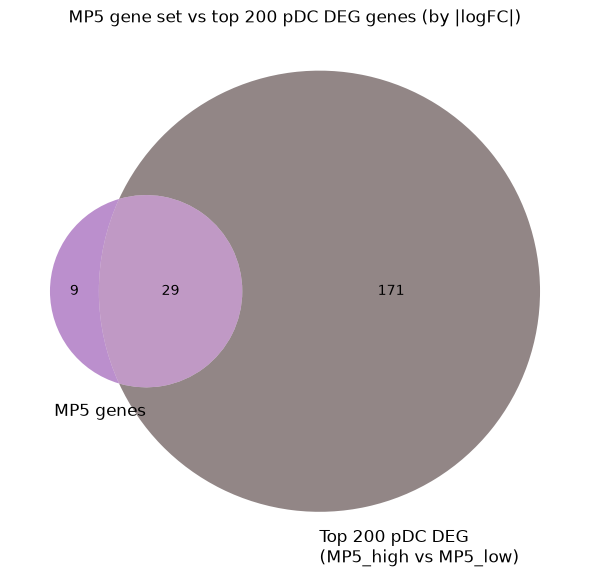

In [27]:
overlap = mp5_genes & deg_genes
print(f"\nOverlap: {len(overlap)} genes")
print(sorted(overlap))
 
fig, ax = plt.subplots(figsize=(6, 6))
venn2(
    [mp5_genes, deg_genes],
    set_labels=("MP5 genes", f"Top {TOP_N_DEG} pDC DEG\n(MP5_high vs MP5_low)"),
    ax=ax,
    set_colors=("#8E44AD", "#493636"),
    alpha=0.6,
)
ax.set_title(f"MP5 gene set vs top {TOP_N_DEG} pDC DEG genes (by |logFC|)")
fig.tight_layout()

out_pdf = os.path.join(OUT_DIR, "10_13_venn_MP5_genes_vs_pDC_DEG.pdf")
# fig.savefig(out_pdf, bbox_inches="tight")
plt.show(fig)
plt.close(fig)


In [11]:
print("\n--- diagnostic: repr of a few gene names from each side ---")
print("mp5_genes sample:", [repr(g) for g in list(mp5_genes)[:5]])
print("deg_df['names'] sample:", [repr(g) for g in deg_df["names"].head(5).tolist()])
 
all_deg_genes = set(deg_df["names"].astype(str))
raw_overlap = mp5_genes & all_deg_genes
print(f"\nOverlap between MP5 genes and ALL {len(deg_df)} tested genes "
      f"(no significance/logFC/top-N filtering): {len(raw_overlap)} genes")
print(sorted(raw_overlap))
 
if raw_overlap:
    print("\nStats for those overlapping genes in the DEG table:")
    print(deg_df[deg_df["names"].isin(raw_overlap)]
          [["names", "logfoldchanges", "pvals_adj"]].to_string(index=False))
    


--- diagnostic: repr of a few gene names from each side ---
mp5_genes sample: ["'LILRA4'", "'PTGDS'", "'PPP1R14B'", "'IRF7'", "'PRXL2A'"]
deg_df['names'] sample: ["'GZMB'", "'PPP1R14B'", "'ITM2C'", "'SERPINF1'", "'IRF7'"]

Overlap between MP5 genes and ALL 22586 tested genes (no significance/logFC/top-N filtering): 38 genes
['APP', 'CCDC50', 'CIB2', 'CLEC4C', 'DERL3', 'DNASE1L3', 'ENSG00000271857', 'GAS6', 'IDH3A', 'IL3RA', 'IRF7', 'IRF8', 'ITM2C', 'JCHAIN', 'LAMP5', 'LGMN', 'LILRA4', 'LINC00996', 'LINC02812', 'LRRC26', 'MYBL2', 'MZB1', 'P2RY14', 'PACSIN1', 'PLD4', 'PPP1R14B', 'PRXL2A', 'PTGDS', 'SCN9A', 'SCT', 'SERPINF1', 'SMPD3', 'ST6GALNAC4', 'TCF4', 'TPM2', 'TRAF4', 'UGCG', 'ZFAT']

Stats for those overlapping genes in the DEG table:
          names  logfoldchanges     pvals_adj
       PPP1R14B        4.365202  0.000000e+00
          ITM2C        4.029866  0.000000e+00
       SERPINF1        5.196849  0.000000e+00
           IRF7        4.752818  0.000000e+00
         CCDC50      

### scatter plot MP5 score vs p_adj value

    x = MP5 gene loading score (kaleidocell NMF weight, from genes.csv)
    y = padj of that gene in the pDC MP5_high vs MP5_low DEG (10_09_deg_pDC_MP5_high_vs_low.csv)

In [53]:
PADJ_SIG_LINE = 0.05


In [91]:
deg_df = pd.read_csv(DEG_PATH)[["names", "logfoldchanges"]].rename(
    columns={"names": "gene", "logfoldchanges": "logFC"}
)
mp5_df = genes_raw.loc[genes_raw["mp"] == "MP5", ["gene", "score"]].rename(
    columns={"score": "mp5_score"}
)
print(f"MP5 gene set: {len(mp5_genes)} genes")


MP5 gene set: 38 genes


In [89]:
deg_df

,gene,logFC
0,GZMB,7.004509
1,PPP1R14B,4.365202
2,ITM2C,4.029866
3,SERPINF1,5.196849
4,IRF7,4.752818
...,...,...
22581,MT-CYB,-1.286918
22582,MS4A1,-8.836304
22583,CD52,-3.039452
22584,KLF2,-6.092267


In [92]:
merged = mp5_df.merge(deg_df, on="gene", how="inner")
n_missing = len(mp5_df) - len(merged)
if n_missing:
    missing_genes = sorted(set(mp5_df["gene"]) - set(merged["gene"]))
    print(f"{n_missing} MP5 genes not found in the DEG table (not tested / "
          f"filtered out earlier): {missing_genes}")
print(f"Plotting {len(merged)} genes")

Plotting 38 genes


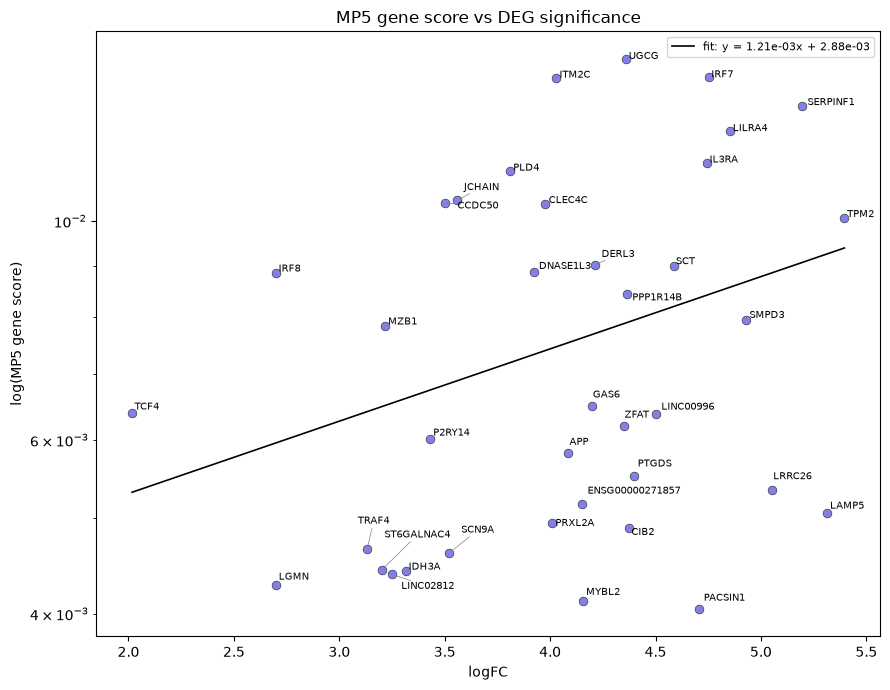


Saved scatter plot to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_13_mp5_score_vs_deg_logfc_scatter_3.pdf


In [97]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(merged["logFC"], merged["mp5_score"], s=40, color="#655fdc",
           edgecolor="black", linewidth=0.4, alpha=0.8)
 
from adjustText import adjust_text
texts = [
    ax.text(row["logFC"], row["mp5_score"], row["gene"], fontsize=7)
    for _, row in merged.iterrows()
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))
 
# linear regression line (least-squares fit, degree 1) - fit direction matches the plot's axes: x = logFC, y = log(MP5 gene score)
slope, intercept = np.polyfit(merged["logFC"], merged["mp5_score"], 1)
x_fit = np.array([merged["logFC"].min(), merged["logFC"].max()])
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, color="black", linewidth=1.2,
        label=f"fit: y = {slope:.2e}x + {intercept:.2e}")
 
ax.set_yscale("log")
ax.set_xlabel("logFC")
ax.set_ylabel("log(MP5 gene score)")
ax.set_title("MP5 gene score vs DEG significance")
ax.legend(fontsize=8)
fig.tight_layout()
 
out_pdf = os.path.join(OUT_DIR, "10_13_mp5_score_vs_deg_logfc_scatter_3.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show(fig)
plt.close(fig)
print(f"\nSaved scatter plot to {out_pdf}")

### UMAP just pDC

In [5]:
ADATA_PATH = f"{BASE}/data/10_integration_GBM_HIHA/gbmap_hiha_concat_harmony.h5ad"
adata = ad.read_h5ad(ADATA_PATH)
print("Loaded:", adata.shape)


Loaded: (208945, 22586)


In [12]:
condition_palette = {"Healthy": "#4C9F70", "GBM": "#C0392B"}


In [7]:
if "condition" in adata.obs.columns:
    condition_col = "condition"
elif "dataset" in adata.obs.columns:
    label_map = {"HIHAtlas": "Healthy", "GBMap": "GBM"}
    adata.obs["condition"] = adata.obs["dataset"].map(label_map)
    condition_col = "condition"
else:
    raise ValueError("Neither 'condition' nor 'dataset' found in adata.obs.")

In [9]:
celltype_col = "decoupler_level1_celltype"
pdc_label = "pDC"

adata_pdc = adata[adata.obs[celltype_col] == pdc_label].copy()


In [10]:
hiha_genes_df = pd.read_csv(GENES_PATH)
mp5_df = hiha_genes_df[hiha_genes_df["mp"] == "MP5"]
gene_weights = dict(zip(mp5_df["gene"], mp5_df["score"]))
 
genes_present = [g for g in gene_weights if g in adata_pdc.var_names]
print(f"MP5: {len(genes_present)} of {len(gene_weights)} genes present in data")
weights = np.array([gene_weights[g] for g in genes_present])
gene_idx = [adata_pdc.var_names.get_loc(g) for g in genes_present]
 
X_sub = adata_pdc[:, gene_idx].X
if sp.issparse(X_sub):
    X_sub = X_sub.toarray()
 
adata_pdc.obs["HIHA_MP5_score"] = np.asarray((X_sub * weights).sum(axis=1) / weights.sum()).flatten()
print(adata_pdc.obs["HIHA_MP5_score"].describe())

MP5: 38 of 38 genes present in data
count    11453.000000
mean         0.950577
std          0.775395
min          0.000000
25%          0.205511
50%          0.426701
75%          1.764451
max          2.267789
Name: HIHA_MP5_score, dtype: float64


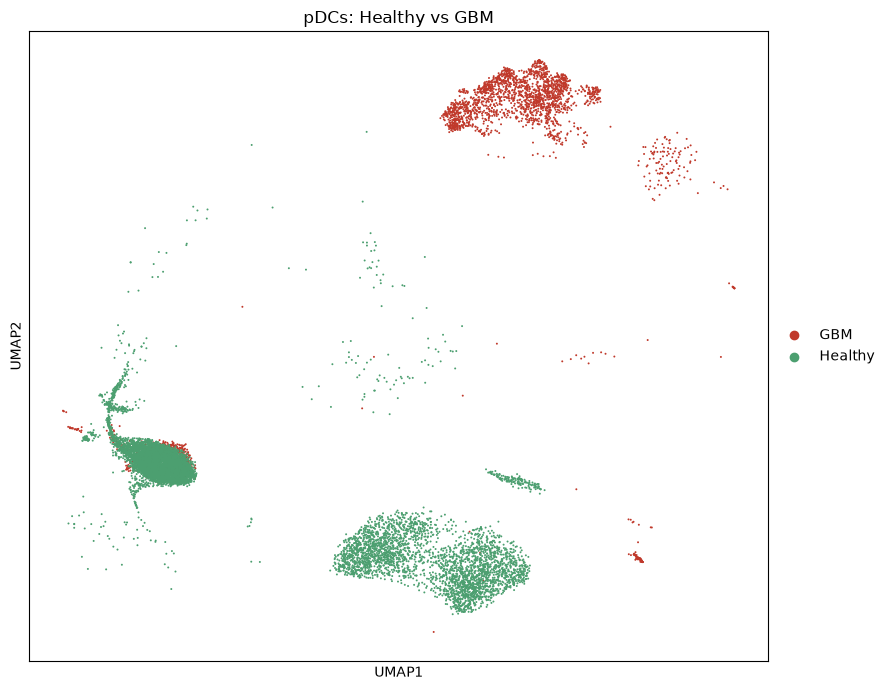


Saved UMAPs to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_13_umap_pDC_condition.pdf


In [40]:
fig, ax = plt.subplots(figsize=(9, 7))
 
sc.pl.umap(
    adata_pdc,
    color=condition_col,
    palette=condition_palette,
    ax=ax,
    show=False,
    size=8,
    title="pDCs: Healthy vs GBM",
    # frameon=False,
)
 
fig.tight_layout()
out_pdf = os.path.join(OUT_DIR, "10_13_umap_pDC_condition.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
plt.close()
print(f"\nSaved UMAPs to {out_pdf}")

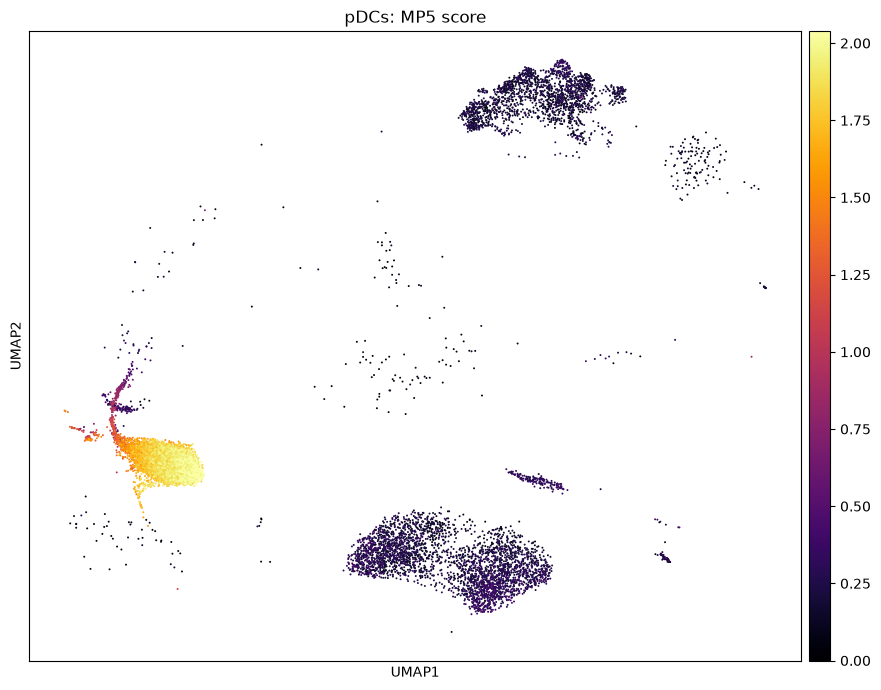


Saved UMAPs to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_13_umap_pDC_MP5score.pdf


In [41]:
fig, ax = plt.subplots(figsize=(9, 7))


sc.pl.umap(
    adata_pdc,
    color="HIHA_MP5_score",
    cmap="inferno",
    vmax="p99",
    ax=ax,
    show=False,
    size=8,
    title="pDCs: MP5 score",
    # frameon=False,
)

fig.tight_layout()
out_pdf = os.path.join(OUT_DIR, "10_13_umap_pDC_MP5score.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show(fig)
plt.close(fig)
print(f"\nSaved UMAPs to {out_pdf}")

In [51]:
MP5_HIGH_THRESHOLD = 1.0

adata_pdc_high = adata_pdc[
    (adata_pdc.obs["HIHA_MP5_score"] >= MP5_HIGH_THRESHOLD)
    & (adata_pdc.obs[condition_col] == "Healthy")
].copy()
print(f"\npDC_high subset, Healthy only (HIHA_MP5_score >= {MP5_HIGH_THRESHOLD}): {adata_pdc_high.shape}")
print(adata_pdc_high.obs[condition_col].value_counts())


pDC_high subset, Healthy only (HIHA_MP5_score >= 1.0): (4923, 22586)
condition
Healthy    4923
Name: count, dtype: int64


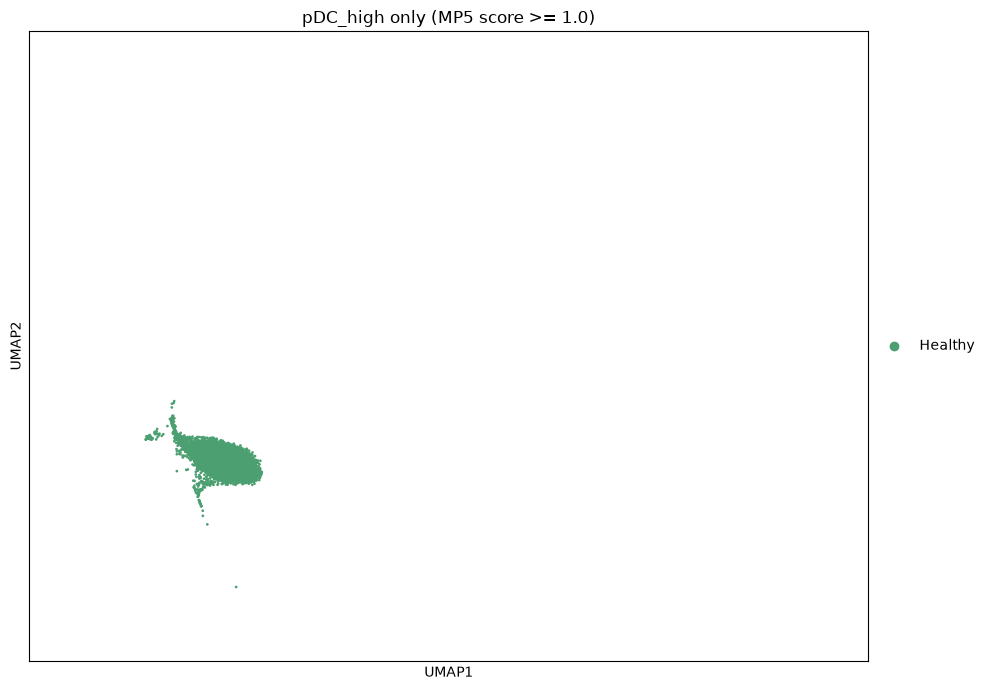


Saved UMAPs to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_13_umap_pDC_high.pdf


In [52]:
umap_all = adata.obsm["X_umap"]
pad = 0.05 * max(np.ptp(umap_all[:, 0]), np.ptp(umap_all[:, 1]))
xlim = (umap_all[:, 0].min() - pad, umap_all[:, 0].max() + pad)
ylim = (umap_all[:, 1].min() - pad, umap_all[:, 1].max() + pad)

fig, ax = plt.subplots(figsize=(10, 7))

sc.pl.umap(
    adata_pdc_high,
    color=condition_col,
    palette=condition_palette,
    ax=ax,
    show=False,
    size=15,
    title=f"pDC_high only (MP5 score >= {MP5_HIGH_THRESHOLD})",
)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

fig.tight_layout()
out_pdf = os.path.join(OUT_DIR, "10_13_umap_pDC_high.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show(fig)
plt.close(fig)
print(f"\nSaved UMAPs to {out_pdf}")